In [4]:
from dotenv import load_dotenv
import os
from langchain_openai import ChatOpenAI
from pydantic import BaseModel,Field

load_dotenv()

llm=ChatOpenAI(model="deepseek-chat",
               base_url=os.getenv("DEEPSEEK_BASE_URL"),
               api_key=os.getenv("DEEPSEEK_API_KEY"),
               temperature=0)

In [5]:
from typing import TypedDict
from langchain_core.messages import SystemMessage,HumanMessage
from IPython.display import display,Image

class ParentState(TypedDict):
    parent_input:str
    final_answer:str

def parent_node(state:ParentState):
    messages=state['parent_input']
    result=llm.invoke(messages)
    return {'final_answer':result}


    
class SubState(TypedDict):
    final_answer:str
    summary_answer:str

def subgraph_node1(state:SubState):
    system_prompt="将收到的消息总结，总结成不超过30个字"
    answer=state['final_answer']
    result=llm.invoke([SystemMessage(content=system_prompt),answer])
    print('subgraph_node1',result)
    return {'summary_answer':answer.content,'final_answer':result.content}

def subgraph_node2(state:SubState):
    system_prompt="分析拿到的回答和总结后的回答，进行打分，满分10分"
    result=llm.invoke([SystemMessage(content=system_prompt),HumanMessage(content=state['summary_answer']),
                HumanMessage(content=state['final_answer'])])
    return {'final_answer':result}

In [6]:
from langgraph.graph import END, START, StateGraph


subgraph_builder=StateGraph(SubState)

subgraph_builder.add_node('subgraph_node1',subgraph_node1)
subgraph_builder.add_node('subgraph_node2',subgraph_node2)

subgraph_builder.add_edge(START,'subgraph_node1')
subgraph_builder.add_edge('subgraph_node1','subgraph_node2')
subgraph_builder.add_edge('subgraph_node2',END)

subgraph=subgraph_builder.compile()

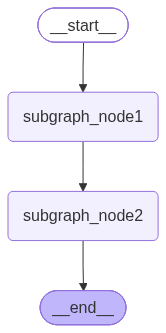

In [7]:
display(Image(subgraph.get_graph(xray=True).draw_mermaid_png()))

In [8]:
parent_builder=StateGraph(ParentState)

parent_builder.add_node('parent_node',parent_node)
parent_builder.add_node('subgraph',subgraph)

parent_builder.add_edge(START,'parent_node')
parent_builder.add_edge('parent_node','subgraph')
parent_builder.add_edge('subgraph',END)

parent_graph=parent_builder.compile()

In [ ]:
print(parent_graph.get_graph(xray=True).draw_mermaid())

# display(Image(parent_graph.get_graph(xray=True).draw_mermaid_png()))


ValueError: Failed to reach https://mermaid.ink API while trying to render your graph. Status code: 400.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

In [12]:
async for chunk in parent_graph.astream({"parent_input":"你好，介绍一下你自己"},stream_mode="values"):
    print(chunk)

{'parent_input': '你好，介绍一下你自己'}
{'parent_input': '你好，介绍一下你自己', 'final_answer': AIMessage(content='你好呀！很高兴认识你！😊\n\n我是**DeepSeek**，由深度求索公司创造的AI助手。让我给你介绍一下我的“特长”：\n\n✨ **我的能力**：\n- **知识广博**：我的知识截止到2025年5月，涵盖各个领域\n- **超强上下文**：支持1M上下文，可以一次性处理《三体》三部曲那么大的内容！\n- **多格式支持**：能处理图片、PDF、Word、Excel、PPT等多种文件格式\n- **联网搜索**：需要时可以帮你搜索最新信息（需要你手动开启哦）\n- **完全免费**：没错，我是免费的！没有任何收费计划\n\n📱 **使用方式**：\n- 网页版、App都可以用\n- App支持语音输入，非常方便\n- 可以在官方应用商店下载\n\n🎯 **我的风格**：\n我喜欢用热情、细腻的方式和你交流，力求让每次对话都温暖而有帮助。无论是学习、工作还是生活中的问题，我都会认真对待，努力给你最好的答案！\n\n有什么我可以帮你的吗？尽管问，我随时准备着！💪', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 233, 'prompt_tokens': 8, 'total_tokens': 241, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0}, 'prompt_cache_hit_tokens': 0, 'prompt_cache_miss_tokens': 8}, 'model_provider': 'openai', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'a26a7955944dc5c60445bff77fac9c8e', 'id': '78bb58b0-b16d-4071-842c-ef37c